## 02. Model Creation and Data Splitting/Vectorization

- Model Creation notebook for baseline model: Naive Bayes and unparametered Random Forest

In [42]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[0]))

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from src import tuning
import pandas as pd

df = pd.read_csv('../data/processed/sms_data_cleaned.csv')
df.head()

,date,year,month,punctuation_count,word_count,text_count,carrier_Smart,carrier_Globe,carrier_DITO,carrier_Unknown,dedup_group_id,text_transformed,target
0,2026-07-01 09:13:32.668,2026,July,8,20,120,0,0,0,1,0,login free spin marami nakakuha moneytoken sus...,2
1,2026-04-23 01:01:22.884,2026,April,4,27,148,1,0,0,0,1,condo across ateneo torre lorenzo studio units...,2
2,2026-03-27 06:23:44.260,2026,March,6,32,164,1,0,0,0,2,papalduhin kita moneytoken ngayon basta bahala...,1
3,2026-02-17 10:25:35.838,2026,February,11,35,182,1,0,0,0,3,boss panalunin kita pinata win moneytoken haba...,1
4,2026-01-19 16:13:33.766,2026,January,5,19,106,1,0,0,0,4,nagsisimula saya panalo moneytoken free moneyt...,2


## Consolidating Data Leakages

In [44]:
# subset the data
X = df['text_transformed']
y = df['target']

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

train_idx, test_idx = next(sgkf.split(X, y, groups=df['dedup_group_id']))
train_df = df.iloc[train_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

print(f"Training Data Size: {len(train_df)} | Testing Data Size: {len(test_df)}")

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.9, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df['text_transformed'])
X_test = vectorizer.transform(test_df['text_transformed'])

y_train = train_df['target']
y_test = test_df['target']

Training Data Size: 817 | Testing Data Size: 204


## Naive Bayes (MultinomialNB)

In [45]:
_nb = MultinomialNB(alpha=0.5)

_nb.fit(X_train, y_train)
y_pred = _nb.predict(X_test)
y_prob = _nb.predict_proba(X_test)

tuning.show_metrics(y_test, y_pred, y_prob)

=== Classifier Metrics ===
ROC AUC Score: 0.89007
Accuracy Score: 0.73039

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.65      0.71        54
           1       0.71      0.80      0.75        82
           2       0.73      0.71      0.72        68

    accuracy                           0.73       204
   macro avg       0.74      0.72      0.73       204
weighted avg       0.73      0.73      0.73       204



### ROC Curve

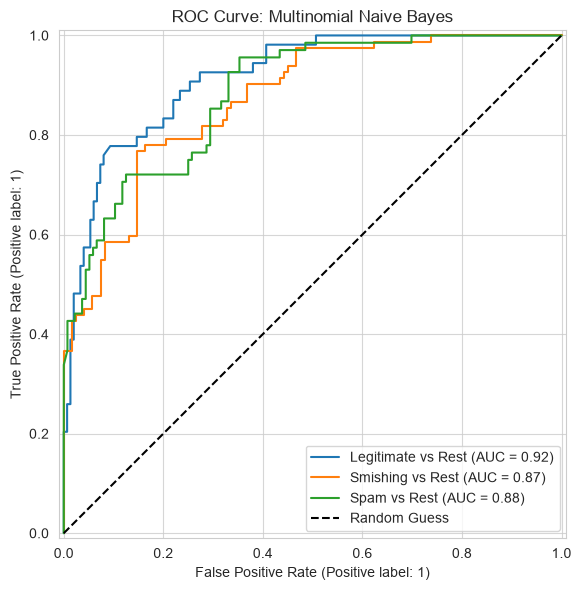

In [46]:
tuning.plot_curve(_nb, X_test, y_test, "Multinomial Naive Bayes")

## Confusion Matrix

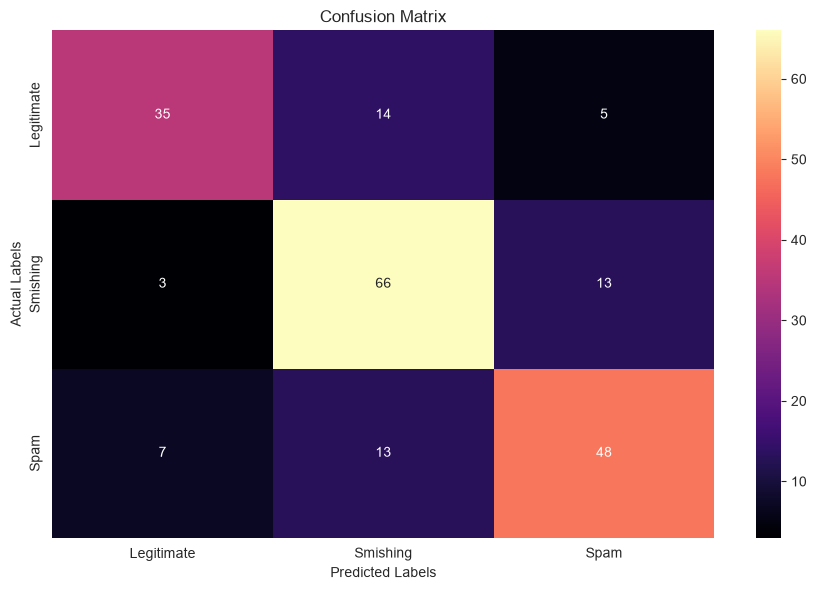

In [47]:
tuning.plot_matrix(y_test, y_pred)

## Random Forest Classifier

In [48]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

tuning.show_metrics(y_test, y_pred_rf, y_prob_rf)

=== Classifier Metrics ===
ROC AUC Score: 0.90100
Accuracy Score: 0.78922

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.85      0.78        54
           1       0.81      0.87      0.84        82
           2       0.85      0.65      0.73        68

    accuracy                           0.79       204
   macro avg       0.79      0.79      0.78       204
weighted avg       0.80      0.79      0.79       204



## ROC - AUC Curve

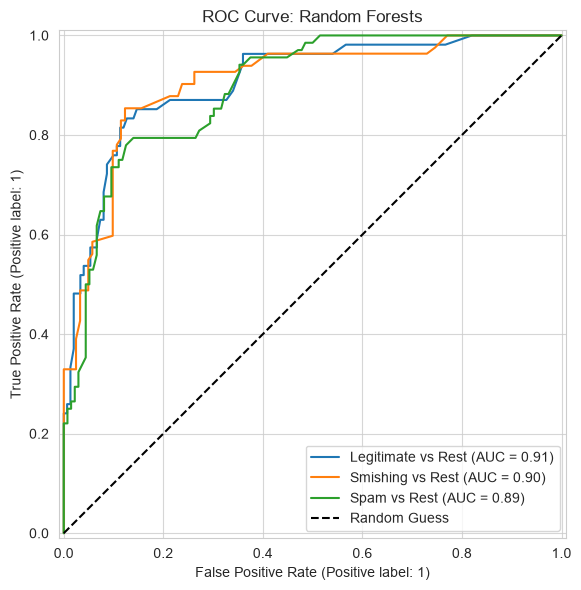

In [49]:
tuning.plot_curve(rf, X_test, y_test, 'Random Forests')

## Confusion Matrix

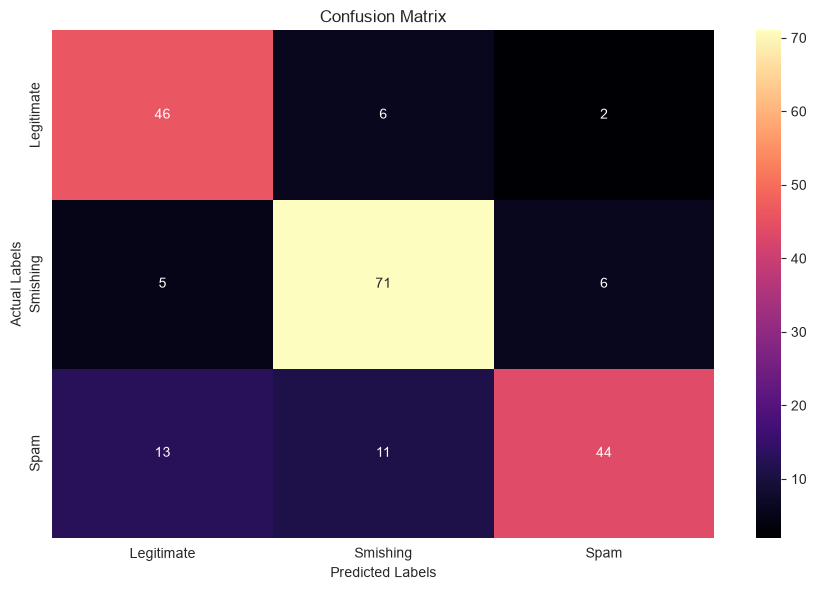

In [50]:
tuning.plot_matrix(y_test, y_pred_rf)